# Assignment 1: Planetary Motion with `Vec3D`

**6EMA02 Particle-based Simulations, 2026-2027 edition**
N-body gravity in C · integrators · conservation · a real asteroid

## How this assignment is assessed: read this first

This notebook is both the assignment text and your report. Task cells
(like this one) are the assignment text and are marked read-only. Jupyter
enforces that; some editors (VS Code among them) do not, so simply leave
them untouched either way: hand-ins are checked against the released
notebook, and modified task cells are flagged. You write your answers in
the cells below each task and hand in this same notebook, **executed**,
together with an HTML export, your code, and the data files the notebook
loads (layout at the end of this notebook).

Your report is **not graded on its content**. Its result is determined in
the individual oral examination at the end of the quartile: the exam is a
conversation about *your* code and *your* results, with this notebook on
screen. Write it as your defence dossier: concise, bullet answers are
fine, every claim something you can stand behind. A report you never hand
in scores 0 for its weight in the final grade; a handed-in report's
result *is* your oral grade.

**AI and sources.** You may use AI assistants (ChatGPT, Claude, Copilot,
…) freely in this course, for code, analysis, and text. Declare the use
briefly in the *Sources* section below, along with any other external
sources: anything in your submission (code, text, data, results) that
your group did not produce itself. Declared sources are never penalised:
nobody grades the text of your report or the style of your code. The oral
examination assesses what *you* understand about the simulation you hand
in. Anything in your submission is fair game, and "we didn't write that
part" is not an available answer. Presenting undeclared external work as
your own is academic misconduct and is treated as such.

## Group

- **Group ID:** group_A1_12
- **Members:** Tomas Dadikozyan (1959123), Paolo Zichella (2376822)

## Setting up your working environment

You need two toolchains: a C compiler for the simulation, and Python with
Jupyter for the analysis in this notebook.

**C compiler.** Linux and macOS have `gcc` (or `clang` aliased to it).
On Windows, install MSYS2 and use its `gcc`, or work inside WSL. Check
with `gcc --version`.

**Python.** Work in a virtual environment so this course cannot break
your other Python installations. From the directory holding this
notebook, with `requirements.txt` (Files ▸ Assignments) next to it:

```
python3 -m venv pbs-env
source pbs-env/bin/activate          # Windows: pbs-env\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

That installs NumPy, SciPy, matplotlib, pandas, Jupyter, and the two
helper packages used below. Every session afterwards starts with the
`activate` line. In Jupyter or VS Code, make sure the notebook's kernel
is the `pbs-env` one before you run anything; a notebook running on some
other interpreter is the most common cause of "it works for me but not
for you".

**Two helper scripts** (Files ▸ Assignments), both run from the
directory holding this notebook:

- `nb2html.py` produces the HTML you hand in:
  `python3 nb2html.py A1.ipynb`. It embeds your figures and writes the
  formulas so that they display in Canvas, which blocks the script that
  a plain `jupyter nbconvert` export relies on.
- `check_my_submission.py` checks your zip against the hand-in rules
  *before* you submit: `python3 check_my_submission.py group7_A1.zip
  --release A1.ipynb`, where `--release` points at a freshly downloaded,
  unmodified copy of this notebook. Run it; it catches the mistakes that
  are annoying to repair afterwards.

## The physics: what you are actually solving

Two bodies with masses $m_i$ and $m_j$ at positions $\mathbf{r}_i$ and
$\mathbf{r}_j$ attract each other along the line connecting them.
**Newton's law of universal gravitation** gives the force on body $i$
exerted by body $j$:

$$\mathbf{F}_{ij} = G\, \frac{m_i m_j}{r_{ij}^{3}}\,
\left(\mathbf{r}_j - \mathbf{r}_i\right), \qquad
r_{ij} = \lVert \mathbf{r}_j - \mathbf{r}_i \rVert ,$$

with the gravitational constant $G$. The force points from $i$ towards
$j$ and falls off as $1/r_{ij}^2$ in magnitude. By Newton's third law
$\mathbf{F}_{ji} = -\mathbf{F}_{ij}$, which is why one evaluation per
*pair* suffices. The associated potential energy of the pair is
$-G m_i m_j / r_{ij}$.

With $N$ bodies, each one feels the sum of the pulls of all others, and
**Newton's second law** turns this into a system of coupled second-order
differential equations, the equations of motion:

$$m_i \frac{\mathrm{d}^2 \mathbf{r}_i}{\mathrm{d}t^2} =
\sum_{j \neq i} \mathbf{F}_{ij}
\qquad \Longleftrightarrow \qquad
\frac{\mathrm{d}^2 \mathbf{r}_i}{\mathrm{d}t^2} =
\mathbf{a}_i = \sum_{j \neq i} G\, \frac{m_j}{r_{ij}^{3}}\,
\left(\mathbf{r}_j - \mathbf{r}_i\right).$$

Note what happened in the second form: the mass of body $i$ cancelled.
Its acceleration depends only on the masses of the *other* bodies. Keep
that form in your code (task A2 returns to it).

For $N = 2$ this system is solvable in closed form and gives Kepler's
ellipses. For $N \geq 3$ it is not: there is no general analytical
solution, and the only way forward is to **integrate the equations
numerically**, stepping the state forward in small time steps
$\Delta t$. That is the entire subject of this course. Gravity is the
gentlest possible starting point, because the force law is simple, but
the program you write here has the same skeleton as the molecular
dynamics code of A2: a pair loop that computes forces, an integrator
that advances positions and velocities, and diagnostics that tell you
whether to believe the result.

Because the equations are second order in time, you need **two** vectors
per body to start: a position and a velocity. Together, for all bodies,
these form the *initial state*, and the whole simulation is an initial
value problem. Where that initial state comes from is the subject of the
next cell.

## The data: JPL Horizons snapshots

The initial states are real measurements of the real solar system,
provided as snapshot files.

**Horizons** is the online ephemeris service of NASA's Jet Propulsion
Laboratory (<https://ssd.jpl.nasa.gov/horizons/>). An *ephemeris* is a
table of the positions and velocities of solar-system bodies as a
function of time. Behind Horizons sits JPL's DE441 planetary ephemeris:
a numerical integration of the solar system, fitted to decades of radar
ranging, spacecraft tracking and optical astrometry. For the planets it
is accurate to well under a kilometre over our time span, so for this
assignment Horizons is *the truth*: it is the external reference against
which you **validate** your simulation, exactly the distinction the
lecture notes draw between verification (is my code solving the
equations right?) and validation (are these the right equations, with
the right data?).

Two snapshot files are provided (Files ▸ Data), generated with the
provided `get_from_Horizons.py`:

- `bodies_2026-09-01.dat`: the starting state, 12 bodies, including the
  asteroid 99942 Apophis with mass 0.
- `bodies_2027-09-01.dat`: the same system exactly one year later, for
  the comparison in task C2.

Each line is one body: `id name mass_kg x y z vx vy vz`, in SI units
(metres, metres per second, kilograms), in the ecliptic J2000 frame with
the solar-system barycentre as origin. Lines starting with `#` are a
header describing exactly this. Times are TDB (a uniform dynamical time
scale), which for our purposes differs from UTC by about a minute.

Three details of the data that matter for your results:

1. **Use $G = 6.6743015 \times 10^{-11}\ \mathrm{m^3\,kg^{-1}\,s^{-2}}$.**
   The masses were derived from the $GM$ values Horizons publishes,
   using this $G$, so with it your products $G m$ reproduce those $GM$
   values exactly. Astronomy measures $GM$ far more precisely than $G$
   and $m$ separately.
2. For the moon-bearing outer planets (Jupiter through Pluto) the files
   give the planetary-*system* barycentre and the total system mass
   (planet plus moons), not the planet centre. Think about why that is
   the right point to propagate in a model that contains no moons except
   our own; task C2 asks you about it.
3. **99942 Apophis** is a roughly 370 m asteroid discovered in 2004. On
   13 April 2029 it passes Earth closer than the geostationary satellite
   ring, one of the closest approaches by an object this size in recorded
   history. Its mass is negligible compared with any planet, so the file
   lists it as 0: it is a test particle, which needs no special-casing
   provided you write the equations of motion as above.

## What you will build, and the required vector type

You will write a C program that integrates the equations of motion for
the bodies in a snapshot file, using *velocity-Verlet* and, for
comparison, *Euler-forward*; monitor the conserved quantities; validate
against Horizons; and finally predict the 2029 Apophis close approach.

**Requirement:** all positions, velocities, accelerations, and forces use

```c
typedef struct Vec3D { double x, y, z; } Vec3D;
```

with dynamically allocated arrays (`Vec3D *r, *v, *a;`) and small inline
helper functions for the vector operations:

```c
static inline Vec3D v3(double x, double y, double z);
static inline Vec3D add(Vec3D a, Vec3D b);
static inline Vec3D sub(Vec3D a, Vec3D b);
static inline Vec3D scl(double s, Vec3D a);
static inline double dot(Vec3D a, Vec3D b);
static inline Vec3D cross(Vec3D a, Vec3D b);
static inline double norm(Vec3D a);
```

Writing vector code this way, rather than juggling `x`, `y`, `z`
separately, is what keeps the force routine short enough to read and to
debug. The same type reappears in every code of this course.

## Code map: fill in as you go

The examiner uses this table in the oral to jump straight to your code,
so **make the entries clickable links**: a markdown link with a path
relative to this notebook, for example

```
| B4 forces | [`compute_acc_and_potential`](code/nbody.c) | [run.csv](data/run.csv) |
```

Relative paths only (`code/…`, `data/…`). A link like
`/home/you/pbs/nbody.c` or `C:\Users\you\...` works on your machine and
nowhere else, and everything you link to must be inside the zip you hand
in. `check_my_submission.py` verifies this for you.

| Task | File / function(s) | Data files |
|------|--------------------|------------|
| B1 data structures | [`main`](code/main.c) (`malloc` of `m`, `r`, `v`, `a`) | — |
| B2 vector helpers | [`Vec3D`, `v_out`, `v_add`, `v_sub`, `v_scl`, `v_dot`, `v_cross`, `v_norm`](code/vec3d.h) | — |
| B3 input reader | [`read_initial_conditions`, `read_bodies_by_name`, `count_bodies`](code/io.c) | [bodies_2026-09-01.dat](data/bodies_2026-09-01.dat) |
| B4 forces + potential | [`compute_acc_and_potential`](code/forces.c) | — |
| B5 integrators | [`euler_step`, `verlet_step`, `integrate_step`](code/integrate.c) | — |
| B6 diagnostics | [`write_diagnostics_row`](code/io.c) | [diagnostics.csv](data/diagnostics.csv) |
| B7 trajectory output | [`write_trajectory_frame`](code/io.c) | [trajectory.csv](data/trajectory.csv) |
| C1 sanity checks | [`main`](code/main.c) | … |
| C2 one-year comparison | [`main`](code/main.c) | [bodies_2027-09-01.dat](data/bodies_2027-09-01.dat) |
| C3 conservation tests | [`main`](code/main.c) | … |
| C4 long-time stability | [`main`](code/main.c) | … |
| C5 Apophis | [`main`](code/main.c) | … |

## Sources

**AI tools used:** Claude Code Sonnet 5, medium strength. ChatGPT free.

**Used for:** Explanations, notebook formatting, logic in main.c, debugging issues, as a general way to understand C code and C specific methods, help for A4, and for understanding the difference between Euler and Verlet integrattion meethods.


**Other external sources** (code, text, data, or results not produced by
us): none.


**Parts of the submission with substantial external content:** If AI is considered such, the CLI parsing section in main.py, especially for creating the body_names array.

**What we did ourselves to verify these parts:** Reasoning through the code, asking AI to explain if needed, compiling, commenting everything by hand.

## Build & run log

Exact compile and run commands, machine, and approximate wall-clock time
for each production run whose output sits in `data/`:

- …

## Part A: Modeling (short written answers)

*In the oral you should be able to:* explain why each conserved quantity
is conserved, and which kinds of bug each one can and cannot catch.

### A1) Force algorithm

Write pseudocode, or extensively commented C code, for computing the
gravitational accelerations and the total potential energy with `Vec3D`.

Address explicitly:

- where Newton's third law enters your loop, and which two lines of your
  code implement it;
- the number of pair evaluations per step as a formula in $N$, evaluated
  for the 12 bodies of the snapshot;
- how the potential energy is accumulated in the same loop.

We calculate the gravitational interactions by looping over each unique pair of bodies only once. We use the required `Vec3D` type for positions and accelerations.

The pseudocode is:

```c
// Set all accelerations to zero
for (int i = 0; i < N; i++) {
    a[i] = v3(0.0, 0.0, 0.0);
}

double U = 0.0;

// Loop over every unique pair
for (int i = 0; i < N - 1; i++) {
    for (int j = i + 1; j < N; j++) {

        // Vector from body i to body j
        Vec3D rij_vec = sub(r[j], r[i]);

        // Distance between the bodies
        double rij = norm(rij_vec);

        // Newton's 3rd law: acceleration of i due to j
        a[i] = add(a[i],
                   scl(G * m[j] / (rij * rij * rij), rij_vec));

        // Newton's 3rd law: acceleration of j due to i (equal and opposite force)
        a[j] = add(a[j],
                   scl(-G * m[i] / (rij * rij * rij), rij_vec));

        // Add this pair's potential energy
        U += -G * m[i] * m[j] / rij;
    }
}
```


Newton's third law enters through the two acceleration updates. The acceleration of \(i\) due to \(j\) is

$$
\mathbf a_i = \mathrel{+} Gm_j\frac{\mathbf r_j-\mathbf r_i}{r_{ij}^3},
$$

while the acceleration of \(j\) due to \(i\) is

$$
\mathbf a_j = \mathrel{-} Gm_i\frac{\mathbf r_j-\mathbf r_i}{r_{ij}^3}.
$$

The corresponding forces are equal and opposite, as required by Newton's third law.

Because the loop uses \(j=i+1\), each pair is evaluated only once. The number of pair evaluations is

$$
N_{\mathrm{pairs}}=\frac{N(N-1)}{2}.
$$

For the 12 bodies this gives,

$$
N_{\mathrm{pairs}}
=
\frac{12(12-1)}{2}
=
\boxed{66}.
$$

The total gravitational potential energy is accumulated in the same pair loop. Each pair contributes

$$
U_{ij}=-\frac{Gm_im_j}{r_{ij}},
$$

so the total potential energy is

$$
\boxed{
U=-\sum_{i<j}\frac{Gm_im_j}{r_{ij}}
}.
$$

Each pair is therefore counted exactly once in both the acceleration calculation and the potential-energy calculation.


### A2) Zero-mass bodies

Explain how to treat entries with $m = 0$: they feel gravity but exert
none. Why can you not compute their acceleration as $\mathbf{F}/m$, and
what does your code compute instead? State what a program that divides
by the mass would produce for Apophis, and how you would recognise that
value in your output.

A body with \(m=0\), such as Apophis, still feels gravity from the other bodies but does not exert gravity on them.

The acceleration equation

$$
\mathbf a_i =
\sum_{j\neq i}
Gm_j
\frac{\mathbf r_j-\mathbf r_i}{r_{ij}^3}
$$

does not contain \(m_i\), so Apophis can still be accelerated normally. When Apophis contributes as body \(j\), \(m_j=0\), so its contribution to the acceleration of other bodies is zero.

Therefore, we must **not** calculate acceleration as

$$
\mathbf a_i=\frac{\mathbf F_i}{m_i},
$$

because for Apophis this would give \(0/0\), resulting in `NaN`. Instead, the code calculates \(\mathbf a_i\) directly from the acceleration equation, so the zero-mass case requires no special treatment.

If the code incorrectly divided by \(m_i\), Apophis's acceleration would become `NaN`, followed by its velocity and position during the simulation.


### A3) Integrator formulas

Give the update rules for velocity-Verlet and Euler-forward in terms of
vector operations, and state for each how many force evaluations one
step costs. Mark in the velocity-Verlet scheme where exactly the force
evaluation sits, and say what goes wrong if it sits elsewhere.

An **update rule** tells us how to calculate the position and velocity at the next time step from their current values.

**Euler-forward:**

$$
\mathbf r_i(t+\Delta t)
=
\mathbf r_i(t)+\mathbf v_i(t)\Delta t
$$

$$
\mathbf v_i(t+\Delta t)
=
\mathbf v_i(t)+\mathbf a_i(t)\Delta t
$$

In vector-operation form:

```c
r[i] = add(r[i], scl(dt, v[i]));
v[i] = add(v[i], scl(dt, a[i]));
```

Euler-forward requires **one force evaluation per time step**, using the current positions to calculate a_i(t)\.

**Velocity-Verlet:**

$$
\mathbf v_i\left(t+\frac{\Delta t}{2}\right)
=
\mathbf v_i(t)
+\frac{1}{2}\mathbf a_i(t)\Delta t
$$

$$
\mathbf r_i(t+\Delta t)
=
\mathbf r_i(t)
+
\mathbf v_i\left(t+\frac{\Delta t}{2}\right)\Delta t
$$

**→ Evaluate the force here, using the new positions \(r(t+Delta t)\):**

$$
\boxed{
\mathbf a_i(t+\Delta t)
=
\mathbf a_i[\mathbf r(t+\Delta t)]
}
$$

$$
\mathbf v_i(t+\Delta t)
=
\mathbf v_i\left(t+\frac{\Delta t}{2}\right)
+
\frac{1}{2}\mathbf a_i(t+\Delta t)\Delta t
$$

Velocity-Verlet also requires **one new force evaluation per time step**. The force evaluation must occur **after the position update and before the final half-step velocity update**, because the new acceleration must correspond to the new positions.


### A4) Invariants

Give formulas for $K$, $U$, $E = K + U$, the total angular momentum
$\mathbf{L}$, and $\mathbf{R}_\mathrm{COM}$.

Then answer **as a table**, one row per invariant, with columns: exact
dynamics, velocity-Verlet, Euler-forward, and *what kind of
implementation error a drift in this quantity would signal*. Note
carefully which invariants are conserved *exactly* (up to round-off) by
velocity-Verlet and which only approximately, and which of them notice
the size of the time step at all.

**Formulas:**

$$
K=\sum_i \frac{1}{2}m_i|\mathbf v_i|^2,
\qquad
U=-\sum_{i<j}\frac{Gm_im_j}{r_{ij}},
\qquad
E=K+U
$$

$$
\mathbf L=\sum_i m_i(\mathbf r_i\times\mathbf v_i),
\qquad
\mathbf R_{\mathrm{COM}}
=
\frac{\sum_i m_i\mathbf r_i}{\sum_i m_i}
$$

**Table:**

| Quantity                     | Exact dynamics    | Velocity-Verlet                                             | Euler-forward                                   | Drift/error indicates                                   |
| :--------------------------- | :---------------- | :---------------------------------------------------------- | :---------------------------------------------- | :------------------------------------------------------ |
| \(K\)                        | Not conserved     | Changes with time                                           | Changes with time                               | Incorrect velocity update                               |
| \(U\)                        | Not conserved     | Changes with time                                           | Changes with time                               | Incorrect positions/forces                              |
| \(E=K+U\)                    | Conserved         | Small bounded oscillations | Generally drifts with time                      | Incorrect forces, integrator, or too-large (Delta t) |
| \(L\)                | Conserved         | Conserved up to round-off, independent of (Delta t)      | Conserved up to round-off, independent of (Delta t) | Broken force symmetry (Newton's third law), not \(Delta t) or integrator choice |
| \(R_{COM}\) | Constant velocity | Constant velocity up to round-off, independent of (Delta t) | Constant velocity up to round-off, independent of (Delta t) | Same as above — |


## Part B: C implementation

*In the oral you should be able to:* walk through any function you wrote;
explain your memory layout and what must happen after every `malloc`;
justify where the force evaluation sits inside the velocity-Verlet step.

### B1) Data structures

Dynamically allocate the arrays; keep only the current positions,
velocities, and accelerations in memory (no trajectory history).

### B2) Vector helpers

Implement all helpers listed above and use them consistently.

### B3) Input

Implement `read_initial_conditions(...)` for the snapshot files. Lines
starting with `#` are comments (the header states the columns and
units); skip them.

### B4) Forces

Implement `compute_acc_and_potential(...)` returning accelerations and
the total potential energy, with correct zero-mass handling.

### B5) Integrator switch

An enum plus runtime flag selects Euler-forward or velocity-Verlet.

### B6) Diagnostics

Compute $K$, $U$, $E$, $\mathbf{L}$, $\mathbf{R}_\mathrm{COM}$ per step;
write to CSV.

### B7) Trajectory output

Write positions to file every fixed number of steps (user-selectable).

Document the result in the cell below: list the files you wrote with one
sentence each, state how a reader compiles and runs your program (also
put this in `code/README.md`), and describe how a run is configured
(command-line options, or which constants to edit and recompile).

*Implementation notes (B1-B7):*

**Files.**

- `vec3d.h`: the `Vec3D` struct and inline vector helpers, named
  `v_out`, `v_add`, `v_sub`, `v_scl`, `v_dot`, `v_cross`, `v_norm`. This
  is a deliberate deviation from the bare names (`v3`, `add`, `sub`,
  `scl`, `dot`, `cross`, `norm`) suggested in the assignment text: the
  bare names are common enough words that they risk clashing with
  standard-library symbols or other identifiers across our files, so we
  prefixed all of them with `v_`. Behaviour and signatures otherwise
  match the requirement exactly.
- `io.c`/`io.h`: `count_bodies` and `read_initial_conditions` parse the
  Horizons snapshot files, skipping both `#` comment lines and blank
  lines (a line whose first character is `\n` or `\0`, e.g. a trailing
  empty line at end of file) (B3); `read_bodies_by_name` restricts a
  run to a named subset of bodies; `write_diagnostics_row` and
  `write_trajectory_frame` write the two output CSVs (B6, B7).
- `forces.c`/`forces.h`: `compute_acc_and_potential` (B4).
- `integrate.c`/`integrate.h`: `euler_step`, `verlet_step`, and the
  runtime-selectable `integrate_step` dispatcher, driven by the
  `Integrator_type` enum (B5).
- `main.c`: command-line parsing, `malloc` of the `m`, `r`, `v`, `a`
  arrays (B1), the initial force evaluation, and the main time loop.

**Compiling and running.** See `code/README.md` for the exact build
command and command-line options. In short:

```
gcc -O2 -o main main.c io.c forces.c integrate.c -lm
./main --integrator verlet --dt 3600 --steps 10 --trajectory-every 2
```

**Configuring a run.** Everything needed to configure a production run
is a command-line flag: `--integrator euler|verlet`, `--dt` (seconds),
`--steps`, `--trajectory-every`, `--diagnostics-every`, and `--bodies`
(comma-separated subset of body names, e.g. `--bodies Sun,Earth,Moon`;
omit for all bodies in the input file). `--diagnostics-every` thins out
how often a diagnostics row is written without changing how often
forces are computed, so it only trades diagnostics.csv size against
resolution, not accuracy; it matters for the long C4/C5 runs, where
writing a row every step would produce millions of rows. The input file
itself is currently the one constant that needs editing and
recompiling if you want a run from `bodies_2027-09-01.dat` instead of
the 2026 snapshot.

**Memory.** Only the current-step `m`, `r`, `v`, `a` arrays are kept
(no trajectory history in memory); each is freed at the end of `main`
on every exit path, including the early-return error paths after a
failed `malloc` or a failed file read.

## Part C: Validation and analysis

*In the oral you should be able to:* say what the Horizons comparison
validates that the conservation tests cannot; predict how each error
changes when the time step is halved; explain why the Apophis prediction
is so much more demanding than the planetary orbits.

Every figure below needs axis labels with units, a legend where more
than one curve appears, and a caption or a sentence in the text stating
what it shows and what the reader should conclude from it. Report
numbers with a sensible number of digits: significant, not all of them.

### C1) Sanity checks

Simulate Sun and Earth (2 bodies), then Sun, Earth and Moon (3 bodies),
using velocity-Verlet.

Deliver:

- a **figure** of the Earth's orbit around the Sun in the ecliptic plane
  ($x$ versus $y$ in AU, equal aspect ratio, Sun marked);
- a **figure** of the Earth-Moon distance against time for the 3-body
  run, over at least three months;
- a **table** with your fitted orbital periods next to the literature
  values (sidereal year 365.256 d, sidereal month 27.322 d) and the
  deviation of each;
- a **figure** of the relative energy error against time for both runs.

Then comment: before trusting the second decimal of the fitted year,
think about what the snapshot's Earth velocity contains. It is the state
of the Earth *body*, in a system from which you have removed bodies.
Does that raise or lower the period, and by roughly how much?

*Results (C1):*

- **Earth's orbit:** a closed ellipse around the Sun, as expected for a 2-body Kepler problem.

- **Earth-Moon distance:** the perigee/apogee envelope (roughly 357,000-407,000 km) isn't fixed — it slowly shrinks and grows back with a period of about 200 days (two full cycles over the 1-year run). The reason is that the Sun pulls on the Moon too, not just on Earth. When the Moon lines up with the Sun and Earth, the Sun's extra pull stretches the Moon's orbit; a couple of weeks later, at a different angle, it squeezes the orbit instead. Because the Moon's orbit slowly rotates relative to the Sun-Earth line, this stretch-and-squeeze pattern repeats roughly every 200 days. It's real physics, not a bug: energy conservation stays flat at $10^{-9}$ throughout (see below), and the envelope keeps returning instead of drifting away.

- **Periods:** the fitted Earth period comes out at 364.39 d, about 0.24% (0.86 days) short of the sidereal year — see the note below for why. The fitted Moon period from the 3-month run (27.36 d) is 0.13% off; fitting the same way on the full 1-year run instead gives 27.32 d, only 0.01% off. The fit draws a straight line through the Moon's unwrapped orbital angle, so it averages over everything the run covers: 3 months only catches part of one 200-day stretch-squeeze cycle, so the fit is biased; a full year covers about two whole cycles, and that bias cancels out. So the improvement from 3 months to 1 year is the fit averaging out the perturbation above, not the integrator becoming more accurate.

  What "the straight line" actually is: at each saved timestep we know the Moon's position relative to Earth, and we turn that into a single number, the angle of that position — think of it as the angle of a clock hand pointing from Earth to the Moon. As the Moon goes around, that angle should just keep increasing at a steady rate: $0$ at the start, $2\pi$ after one full orbit, $4\pi$ after two orbits, and so on (we "unwrap" it so it keeps climbing instead of resetting to zero every lap). If we plot this ever-increasing angle against time, the result is close to a straight line, because the Moon sweeps out roughly equal angle in equal time. The slope of that line is the average angular speed, and dividing $2\pi$ by the slope gives the period. Fitting the line uses every one of the thousands of hourly samples in the run at once — not a measurement of just one orbit — which is why a single noisy or perturbed sample barely shifts the line, and why covering more full cycles (1 year vs. 3 months) makes the average more accurate.

- **Energy conservation:** relative energy error stays bounded around $10^{-9}$ for velocity-Verlet, for both the 2-body run and all three lengths of the 3-body run — it does not grow as the run gets longer. This matches velocity-Verlet being symplectic (A4), and confirms that the distance drift above is real orbital motion, not integration error.

- **Before trusting the second decimal of the fitted year:** the Earth velocity in the snapshot isn't the velocity of a smooth, Moon-free orbit — it's Earth's actual velocity, which wobbles a little as Earth and the Moon swing around their common centre of mass (Earth's share of that wobble is about 12 m/s, against an orbital speed around the Sun of roughly 30 km/s, so about 0.04% of it). Feed that real, wobbly velocity into a 2-body Sun-Earth simulation and the orbit you get isn't quite the smooth one: a slightly faster-than-average snapshot velocity gives a slightly smaller orbit and a shorter period; a slightly slower one would raise it instead. Which way it goes depends on where Earth happened to be in its monthly wobble at the snapshot moment, so it isn't predictable in advance — but its size is set by that ~0.04% velocity offset, and the period is roughly three times as sensitive to velocity as the offset itself, so a few tenths of a percent (a fraction of a day) is the expected order of magnitude. That's exactly what we see here (0.24%), and it's larger than the second decimal place, so that digit shouldn't be trusted from this run.

In [1]:
# C1: load Sun-Earth and Sun-Earth-Moon runs, fit orbital periods

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AU = 1.495978707e11
DAY = 86400.0

SIDEREAL_YEAR = 365.256    # days
SIDEREAL_MONTH = 27.322    # days


# ---------- Load trajectories ----------
# 2-body run: body 0 = Sun, body 1 = Earth (bodies are emitted in the
# order they appear in the input file, not the order given to --bodies;
# see code/README.md)
traj_2b = pd.read_csv("data/C1/traj_1h_2y_S_E.csv")
diag_2b = pd.read_csv("data/C1/diag_1h_2y_S_E.csv")

# 3-body run: body 0 = Sun, body 1 = Earth, body 2 = Moon
traj_3b = pd.read_csv("data/C1/traj_1h_3m_3b.csv")
diag_3b = pd.read_csv("data/C1/diag_1h_3m_3b.csv")

# Same 3-body run, carried on for 6 months and for a full year (same dt,
# same initial conditions), used for the longer-baseline distance and
# energy figures below.
traj_6b = pd.read_csv("data/C1/traj_1h_6m_3b.csv")
diag_6b = pd.read_csv("data/C1/diag_1h_6m_3b.csv")

traj_1y = pd.read_csv("data/C1/traj_1h_1y_3b.csv")
diag_1y = pd.read_csv("data/C1/diag_1h_1y_3b.csv")


def body_xyz(traj, body_id):
    rows = traj[traj["body"] == body_id].sort_values("t")
    return rows["t"].to_numpy(), rows[["x", "y", "z"]].to_numpy()


t_2b, r_sun_2b = body_xyz(traj_2b, 0)
_,    r_earth_2b = body_xyz(traj_2b, 1)

t_3b, r_earth_3b = body_xyz(traj_3b, 1)
_,    r_moon_3b = body_xyz(traj_3b, 2)

t_6b, r_earth_6b = body_xyz(traj_6b, 1)
_,    r_moon_6b = body_xyz(traj_6b, 2)

t_1y, r_earth_1y = body_xyz(traj_1y, 1)
_,    r_moon_1y = body_xyz(traj_1y, 2)


# ---------- Fit orbital periods from the unwrapped orbital angle ----------
# Fitting a straight line to the unwrapped angle (rather than timing a
# single zero-crossing) averages over every sample of every orbit in the
# run, which is far less sensitive to the other body's perturbation than
# a single-period measurement would be.

def fit_period(t, rel_pos):
    angle = np.unwrap(np.arctan2(rel_pos[:, 1], rel_pos[:, 0]))
    slope, _ = np.polyfit(t, angle, 1)    # rad/s
    return 2 * np.pi / abs(slope)         # s


earth_rel_sun = r_earth_2b - r_sun_2b
period_earth = fit_period(t_2b, earth_rel_sun) / DAY

moon_rel_earth = r_moon_3b - r_earth_3b
period_moon = fit_period(t_3b, moon_rel_earth) / DAY

moon_rel_earth_1y = r_moon_1y - r_earth_1y
period_moon_1y = fit_period(t_1y, moon_rel_earth_1y) / DAY


period_table = pd.DataFrame({
    "Orbit": ["Earth around Sun (2 y run)",
              "Moon around Earth (3-month run)",
              "Moon around Earth (1-year run)"],
    "Fitted period [d]": [period_earth, period_moon, period_moon_1y],
    "Literature [d]": [SIDEREAL_YEAR, SIDEREAL_MONTH, SIDEREAL_MONTH],
})

period_table["Deviation [%]"] = (
    100 * (period_table["Fitted period [d]"] - period_table["Literature [d]"])
    / period_table["Literature [d]"]
)

period_table


,Orbit,Fitted period [d],Literature [d],Deviation [%]
0,Earth around Sun (2 y run),364.394743,365.256,-0.235795
1,Moon around Earth (3-month run),27.356708,27.322,0.127032
2,Moon around Earth (1-year run),27.324422,27.322,0.008866


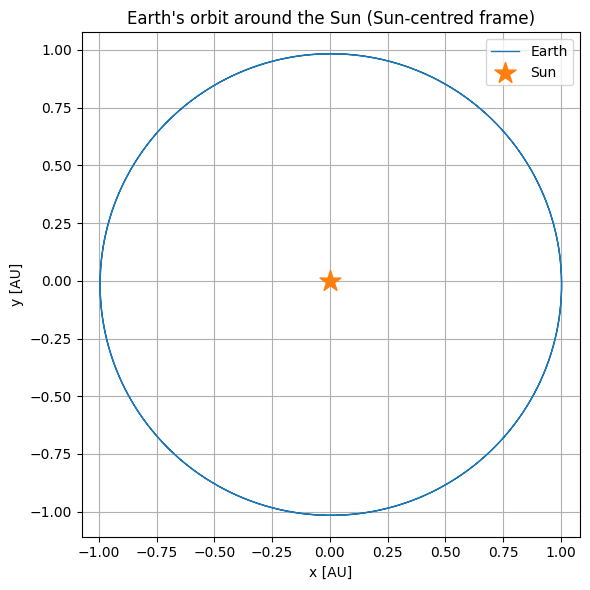

In [2]:
# C1: Earth's orbit around the Sun (2-body run)
# Plotted in the Sun-centred frame (Earth position minus Sun position)
# so the Sun sits at the origin and the ellipse is easy to read.

plt.figure(figsize=(6, 6))

plt.plot(
    (r_earth_2b[:, 0] - r_sun_2b[:, 0]) / AU,
    (r_earth_2b[:, 1] - r_sun_2b[:, 1]) / AU,
    color="tab:blue",
    linewidth=1,
    label="Earth"
)

plt.scatter(
    0, 0,
    color="tab:orange",
    marker="*",
    s=250,
    label="Sun",
    zorder=3
)

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Earth's orbit around the Sun (Sun-centred frame)")

plt.axis("equal")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


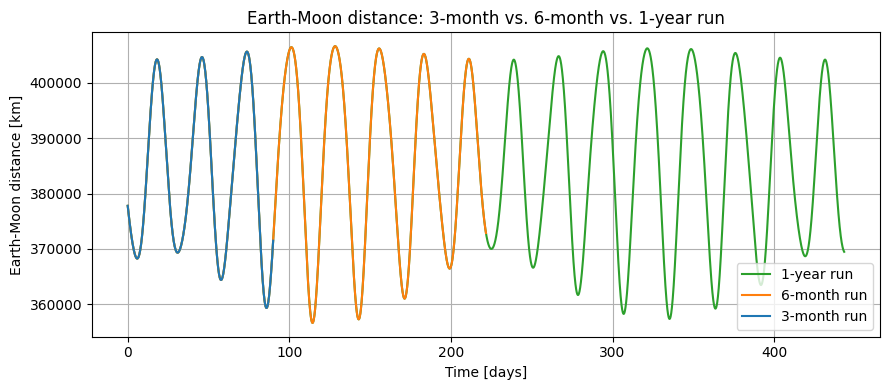

In [3]:
# C1: Earth-Moon distance, 3-month vs. 6-month vs. 1-year run

earth_moon_distance_3b = np.linalg.norm(moon_rel_earth, axis=1)
earth_moon_distance_6b = np.linalg.norm(r_moon_6b - r_earth_6b, axis=1)
earth_moon_distance_1y = np.linalg.norm(moon_rel_earth_1y, axis=1)

plt.figure(figsize=(9, 4))

plt.plot(t_1y / DAY, earth_moon_distance_1y / 1e3,
         label="1-year run", color="tab:green")
plt.plot(t_6b / DAY, earth_moon_distance_6b / 1e3,
         label="6-month run", color="tab:orange")
plt.plot(t_3b / DAY, earth_moon_distance_3b / 1e3,
         label="3-month run", color="tab:blue")

plt.xlabel("Time [days]")
plt.ylabel("Earth-Moon distance [km]")
plt.title("Earth-Moon distance: 3-month vs. 6-month vs. 1-year run")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


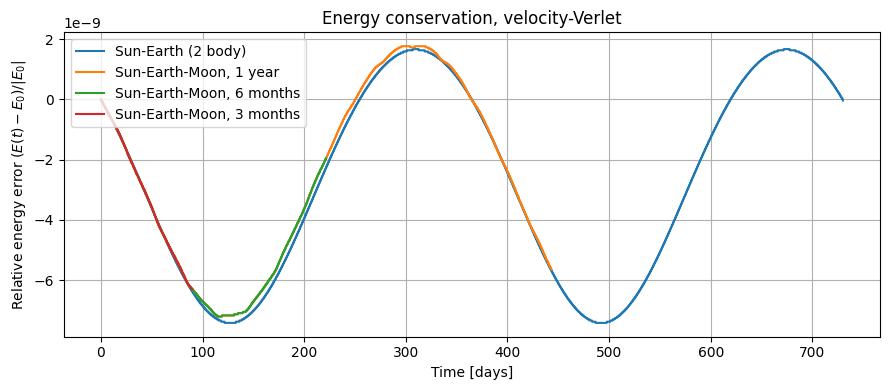

In [4]:
# C1: relative energy error against time for all runs

E0_2b = diag_2b["E"].iloc[0]
rel_err_2b = (diag_2b["E"] - E0_2b) / abs(E0_2b)

E0_3b = diag_3b["E"].iloc[0]
rel_err_3b = (diag_3b["E"] - E0_3b) / abs(E0_3b)

E0_6b = diag_6b["E"].iloc[0]
rel_err_6b = (diag_6b["E"] - E0_6b) / abs(E0_6b)

E0_1y = diag_1y["E"].iloc[0]
rel_err_1y = (diag_1y["E"] - E0_1y) / abs(E0_1y)

plt.figure(figsize=(9, 4))

plt.plot(diag_2b["t"] / DAY, rel_err_2b, label="Sun-Earth (2 body)")
plt.plot(diag_1y["t"] / DAY, rel_err_1y, label="Sun-Earth-Moon, 1 year")
plt.plot(diag_6b["t"] / DAY, rel_err_6b, label="Sun-Earth-Moon, 6 months")
plt.plot(diag_3b["t"] / DAY, rel_err_3b, label="Sun-Earth-Moon, 3 months")

plt.xlabel("Time [days]")
plt.ylabel(r"Relative energy error $(E(t)-E_0)/|E_0|$")
plt.title("Energy conservation, velocity-Verlet")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### C2) One-year comparison against Horizons

Integrate the full 2026 snapshot for exactly one year and compare your
final positions, body by body, with `bodies_2027-09-01.dat`.

Deliver:

- a **figure** showing the state of the system: the positions of all
  bodies in the ecliptic plane at the start and after one year (two
  panels, or one panel with two marker styles). Use a scale on which the
  inner planets are visible, and say which bodies fall outside it;
- a **table** of $\lVert \mathbf{r}_\mathrm{sim} -
  \mathbf{r}_\mathrm{Horizons} \rVert$ per body for **at least three
  time steps** spanning a factor 10 or more;
- a **figure** of those discrepancies (bar chart, logarithmic vertical
  axis, one group of bars per body).

Then discuss: relative to what scale is an error small, for each body?
Which bodies improve when you halve $\Delta t$ and which do not, and
what does that tell you about where the remaining error comes from?

*A question to take to the oral:* the snapshots give the outer planets
as system barycentres with system masses (see the data cell). Estimate
what the one-year discrepancy of Jupiter, and of Pluto whose moon Charon
carries 11% of the system mass, would have been with planet-*centre*
states instead, and why no time step could have fixed it.

### One-year comparison against Horizons

Figure 1 shows the system at the start and after one year. The ±2 AU scale shows the Sun through Mars clearly. Jupiter, Saturn, Uranus, Neptune, and Pluto are outside this range and are therefore not shown.

### Discussion

The position error should be compared with each body's orbital radius. For example, the 1 h error is about \(4.7\*10*^6\) m for Mercury, \(4.3\*10*^2\) m for Jupiter, and 23 m for Uranus. Relative to their orbital radii, these correspond to about \(8\*10*^{-5}\), \(5.5\*10*^{-10}\), and \(8\*10*^{-12}\), respectively. Thus, a small absolute error does not necessarily mean a small relative error.

As \(\Delta t\) is reduced from 24 h to 6 h to 1 h, the errors of most bodies decrease, showing that numerical integration error is important. Jupiter is a clear example, with its error decreasing from \(1.09\*10*^9\) m to \(7.84\*10*^3\) m and then \(4.29\*10*^2\) m. In contrast, Pluto does not improve from 6 h to 1 h (138.5 m → 138.5 m), while Neptune changes only slightly (67.5 m → 66.6 m). This indicates that for these bodies, other sources of error, such as the barycentre-versus-planet-centre representation of the outer planets, become more important than the timestep.

Overall, reducing \(\Delta t\) decreases the numerical integration error, but it does not eliminate all sources of discrepancy with Horizons.


In [5]:
# C2: load data and calculate one-year discrepancies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AU = 1.495978707e11


# ---------- Read snapshot files ----------

def read_snapshot(filename):
    bodies = []
    positions = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            parts = line.split()

            # File format:
            # id  name  mass  x  y  z  vx  vy  vz

            bodies.append(parts[1])

            positions.append([
                float(parts[3]),  # x
                float(parts[4]),  # y
                float(parts[5])   # z
            ])

    return bodies, np.array(positions)


# Initial snapshot: 2026-09-01
bodies_initial, r_initial = read_snapshot(
    "data/bodies_2026-09-01.dat"
)

# Horizons reference: 2027-09-01
bodies_horizons, r_horizons = read_snapshot(
    "data/bodies_2027-09-01.dat"
)


# ---------- Read final simulation positions ----------

def read_final_positions(filename):

    df = pd.read_csv(filename)

    # Select the final time step
    final = df[df["step"] == df["step"].max()]

    # Sort by simulation body index
    final = final.sort_values("body")

    positions = final[["x", "y", "z"]].to_numpy()

    return positions


r_24h = read_final_positions(
    "data/C2/trajectory_24h.csv"
)

r_6h = read_final_positions(
    "data/C2/trajectory_6h.csv"
)

r_1h = read_final_positions(
    "data/C2/trajectory_1h.csv"
)


# ---------- Check number of bodies ----------

print("Number of Horizons bodies:", len(bodies_horizons))
print("Number of simulated bodies:", len(r_24h))

assert len(bodies_horizons) == len(r_24h)
assert len(bodies_horizons) == len(r_6h)
assert len(bodies_horizons) == len(r_1h)


# ---------- Calculate position discrepancies ----------

error_24h = np.linalg.norm(
    r_24h - r_horizons,
    axis=1
)

error_6h = np.linalg.norm(
    r_6h - r_horizons,
    axis=1
)

error_1h = np.linalg.norm(
    r_1h - r_horizons,
    axis=1
)


# ---------- Create table ----------

error_table = pd.DataFrame({
    "Body": bodies_horizons,
    "24 h [m]": error_24h,
    "6 h [m]": error_6h,
    "1 h [m]": error_1h
})

error_table

Number of Horizons bodies: 12
Number of simulated bodies: 12


,Body,24 h [m],6 h [m],1 h [m]
0,Sun,8.875696e+05,2.808553e+02,2.307792e+02
1,Mercury,6.369524e+09,1.751489e+08,4.701529e+06
2,Venus,3.351999e+09,1.955484e+07,4.500708e+05
3,Earth,2.646012e+09,6.112246e+06,1.187136e+05
4,Moon,2.294810e+09,3.139011e+07,9.456758e+05
5,Mars,2.097260e+09,1.142670e+06,6.083537e+03
6,Jupiter,1.085921e+09,7.838124e+03,4.289634e+02
7,Saturn,8.512844e+08,1.130794e+03,1.203446e+02
8,Uranus,5.820862e+08,7.706015e+01,2.325105e+01
9,Neptune,4.727237e+08,6.751297e+01,6.655825e+01


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


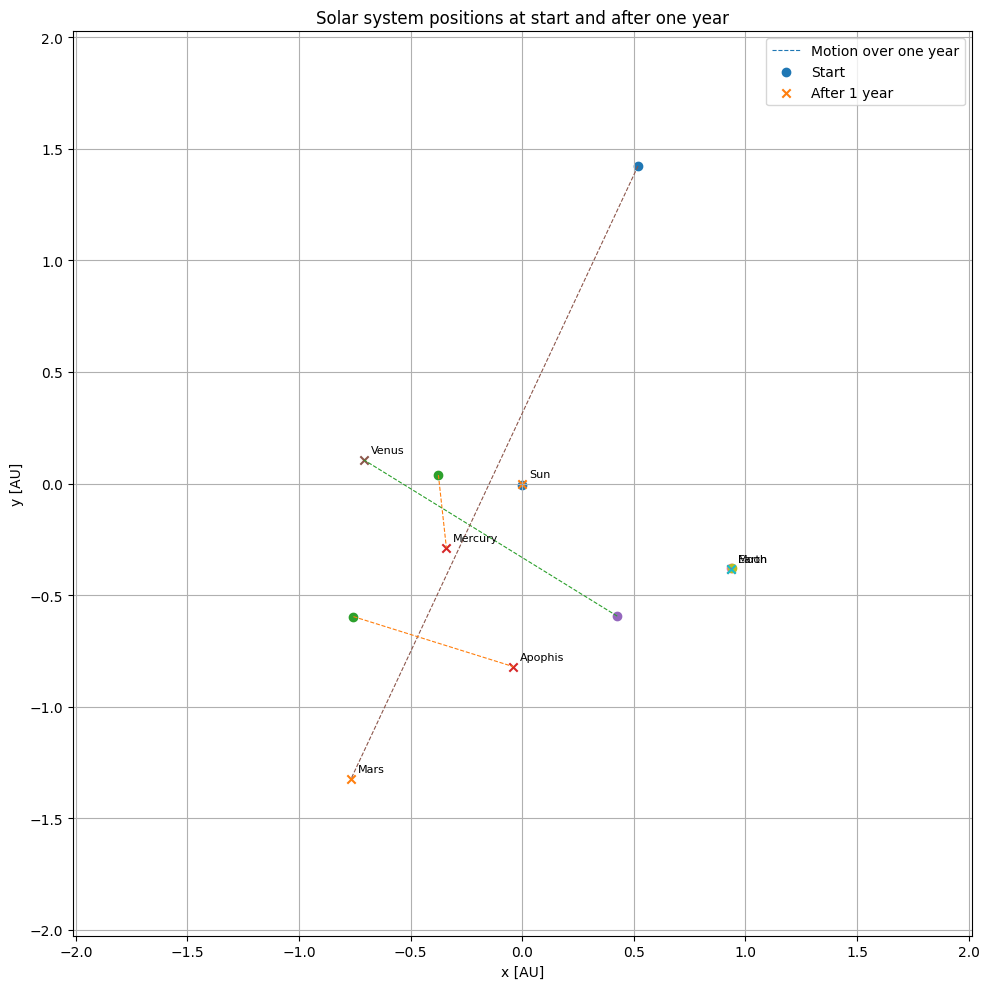

Bodies outside the ±2 AU plotting range:
Jupiter
Saturn
Uranus
Neptune
Pluto


In [6]:
# C2: plot the system at the start and after one year

plt.figure(figsize=(10, 10))

# Plot each body's trajectory from start to final position
for body, r0, r1 in zip(bodies_initial, r_initial, r_1h):

    x0 = r0[0] / AU
    y0 = r0[1] / AU

    x1 = r1[0] / AU
    y1 = r1[1] / AU

    # Line showing movement
    plt.plot(
        [x0, x1],
        [y0, y1],
        linestyle="--",
        linewidth=0.8
    )

    # Start position
    plt.scatter(
        x0,
        y0,
        marker="o"
    )

    # Final position
    plt.scatter(
        x1,
        y1,
        marker="x"
    )

    # Label the final position
    plt.annotate(
        body,
        (x1, y1),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Solar system positions at start and after one year")

plt.legend(
    ["Motion over one year", "Start", "After 1 year"]
)

plt.axis("equal")

# Focus on inner solar system
plt.xlim(-2, 2)
plt.ylim(-2, 2)

plt.grid(True)
plt.tight_layout()
plt.show()


# List bodies outside the plotting range

print("Bodies outside the ±2 AU plotting range:")

for body, pos in zip(bodies_initial, r_1h):

    x = pos[0] / AU
    y = pos[1] / AU

    if abs(x) > 2 or abs(y) > 2:
        print(body)

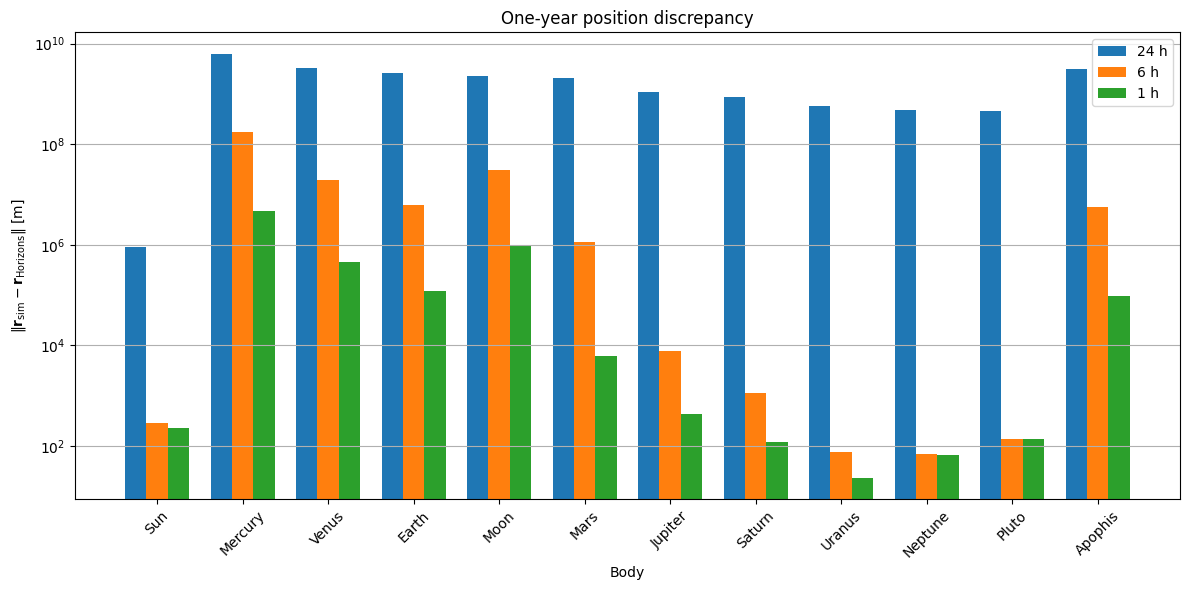

In [7]:
# C2: plot one-year position discrepancies

x = np.arange(len(bodies_horizons))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    error_24h,
    width,
    label="24 h"
)

plt.bar(
    x,
    error_6h,
    width,
    label="6 h"
)

plt.bar(
    x + width,
    error_1h,
    width,
    label="1 h"
)

plt.yscale("log")

plt.xlabel("Body")
plt.ylabel(r"$\|\mathbf{r}_{\mathrm{sim}}-\mathbf{r}_{\mathrm{Horizons}}\|$ [m]")
plt.title("One-year position discrepancy")

plt.xticks(
    x,
    bodies_horizons,
    rotation=45
)

plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

### C3) Conservation tests

Run the full system for one year with **both** integrators at **at least
four** time steps each.

Deliver:

- a **table**: for every integrator and time step, the largest relative
  drift over the run in $E$, in $\lVert\mathbf{L}\rVert$, and in the
  centre-of-mass velocity;
- a **figure**, log-log, of the energy error against $\Delta t$ for both
  integrators, with the fitted slopes stated in the legend or the text;
- a **figure** of the relative energy error against *time* at one common
  time step for both integrators, chosen to show the qualitative
  difference between them.

State the observed orders and whether they match what you predicted in
A3 and A4. Explain the behaviour of $\lVert\mathbf{L}\rVert$ and of the
centre of mass: which of them is a property of the integrator, and which
of the way you wrote the force loop?

*Results (C3):* observed orders …

In [8]:
# C3: drift table; energy error vs dt (log-log) with fitted slopes; error vs time

### C4) Long-time stability

Simulate Sun, Jupiter, Saturn, Uranus, Neptune and Pluto for 200,000
days (about 548 years) with velocity-Verlet.

Deliver:

- a **figure** of the orbits in the ecliptic plane over the whole run;
- a **figure** of the invariants against time (energy, and
  $\lVert\mathbf{L}\rVert$ or the centre-of-mass motion);
- a **table** of the smallest and largest distance to the Sun reached by
  each planet during the run, next to its literature perihelion and
  aphelion.

Then judge the result: do the orbits stay closed and bounded, or is
there a systematic trend? Does the energy error grow with time, and is
that consistent with what you found in C3? Explain how a symplectic
integrator can accumulate a phase error along the orbit while the energy
stays bounded.

*Results (C4):*

- **Orbits stay closed and bounded.** All six bodies trace stable, repeating ellipses in the ecliptic plane over the full 548-year run — no orbit spirals in, spirals out, or drifts away. The Sun's own orbit around the barycentre is far too small to show as a curve on this scale (it stays within a fraction of a solar radius), so it is drawn as a single point instead.

- **Energy error stays bounded, it does not grow.** The relative energy error oscillates in a narrow band, $|\Delta E/E_0| \lesssim 7	imes10^{-8}$, over the whole 200,000-day run, with no systematic upward trend. This is consistent with the order of magnitude found in C3 for velocity-Verlet at this time step, and confirms the same qualitative behaviour (bounded oscillation, not secular drift) still holds after 548 years instead of 1.

- **Angular momentum is conserved to machine/output precision.** $\lVert\mathbf{L}Vert$ does not change at all within the precision written to the diagnostics file (relative error below $10^{-10}$), for every step of the run. This is not really a property of the integrator — it is a property of the force loop: because we compute each pairwise force once and apply it to both bodies with opposite sign (Newton's third law built into the loop, A1), the net torque from internal forces cancels exactly in floating point at every single step, independent of which integrator advances the positions afterwards.

- **The centre of mass drifts, and that is physical, not an error.** $\mathbf{R}_{\mathrm{com}}$ moves away from the origin in a perfectly straight line at a constant rate (≈ 0.16 m/s), reaching about 0.018 AU after 548 years — it is not oscillating or curving. This is the expected signature of *uniform* motion, not a numerical artefact: this subsystem (Sun + 5 outer planets) does not include every body in the real solar system, so its total momentum is not exactly zero in the Horizons snapshot frame, and a system with nonzero total momentum has a centre of mass that coasts at constant velocity by Newton's first law. A symmetric force loop conserves *whatever* momentum the system starts with; it does not make that momentum zero.

- **Perihelion and aphelion match the literature to within half a percent** for all five planets (see table), with no obvious bias toward over- or under-shooting — errors are a mix of signs and are dominated by real modelling choices (Horizons gives barycentric states for the outer planets; literature perihelion/aphelion are long-term averages, not this particular epoch's osculating values) rather than by integration error, since the energy error above is many orders of magnitude smaller than these percent-level differences.

- **Why a symplectic integrator can still accumulate phase error while energy stays bounded.** Velocity-Verlet does not conserve the true Hamiltonian exactly; it conserves a nearby *shadow* Hamiltonian almost exactly, and the true energy oscillates in a bounded band around that shadow value (what we see above). But the *orbital frequency* generated by the shadow Hamiltonian is not quite the true orbital frequency — it is off by an amount set by the time step. That per-orbit frequency offset does not average out: it adds up step after step, orbit after orbit, so the body's *phase* along its orbit (where exactly it is at a given time, i.e. the timing of each perihelion passage) drifts away from the true trajectory linearly with the number of orbits completed, even though the orbit's *shape* (its energy, and therefore its perihelion/aphelion extent) stays correct to the bounded error above. This is exactly why the orbits above still look closed and the extents in the table still match literature well, while a position-vs-time comparison run far enough (as in C2/C5, or here after many more orbits) would eventually show the planet at the wrong point along an otherwise-correct ellipse.

In [ ]:
# C4: outer solar system orbits; invariants and COM motion vs time; perihelion/aphelion table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AU = 1.495978707e11

# ---------- Load trajectory and diagnostics ----------

traj = pd.read_csv("data/C4/trajectory.csv")
diag = pd.read_csv("data/C4/diagnostics.csv")

# Order matches --bodies Sun,Jupiter,Saturn,Uranus,Neptune,Pluto
body_names = ["Sun", "Jupiter", "Saturn", "Uranus", "Neptune", "Pluto"]

# Literature perihelion/aphelion (NASA planetary fact sheet), in AU
literature = {
    "Jupiter": (4.950, 5.458),
    "Saturn":  (9.041, 10.124),
    "Uranus":  (18.286, 20.096),
    "Neptune": (29.81, 30.33),
    "Pluto":   (29.658, 49.305),
}


# ---------- Figure: orbits in the ecliptic plane ----------

plt.figure(figsize=(9, 9))

for i, name in enumerate(body_names):
    b = traj[traj["body"] == i]

    if name == "Sun":
        # The Sun's own orbit (around the barycentre) is far too small to
        # see on this scale, so mark it as a single big point instead of
        # a line.
        plt.scatter(
            b["x"] / AU, b["y"] / AU,
            s=120, color="gold", edgecolor="black",
            zorder=5, label="Sun"
        )
    else:
        plt.plot(b["x"] / AU, b["y"] / AU, linewidth=0.6, label=name)

plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Outer solar system orbits over 200,000 days (~548 years)")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------- Figure: invariants against time ----------

t_years = diag["t"] / (365.25 * 86400)

E0 = diag["E"].iloc[0]
L_norm = np.sqrt(diag["Lx"]**2 + diag["Ly"]**2 + diag["Lz"]**2)
L0 = L_norm.iloc[0]

rel_E_error = (diag["E"] - E0) / abs(E0)
rel_L_error = (L_norm - L0) / abs(L0)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(t_years, rel_E_error, color="tab:blue", label="Relative energy error")
ax1.set_xlabel("t [years]")
ax1.set_ylabel("Relative energy error", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(t_years, rel_L_error, color="tab:red", label="Relative |L| error")
ax2.set_ylabel(r"Relative $\|\mathbf{L}\|$ error", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Conserved quantities over 200,000 days (velocity-Verlet)")
fig.tight_layout()
plt.show()


# ---------- Figure: centre-of-mass motion ----------

Rcom_x_au = diag["Rcom_x"] / AU
Rcom_y_au = diag["Rcom_y"] / AU
Rcom_norm_au = np.sqrt(diag["Rcom_x"]**2 + diag["Rcom_y"]**2 + diag["Rcom_z"]**2) / AU

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(Rcom_x_au, Rcom_y_au)
ax1.scatter(Rcom_x_au.iloc[0], Rcom_y_au.iloc[0], color="green", label="start", zorder=5)
ax1.scatter(Rcom_x_au.iloc[-1], Rcom_y_au.iloc[-1], color="red", label="end", zorder=5)
ax1.set_xlabel("$R_{com,x}$ [AU]")
ax1.set_ylabel("$R_{com,y}$ [AU]")
ax1.set_title("Centre-of-mass path")
ax1.axis("equal")
ax1.legend()
ax1.grid(True)

ax2.plot(t_years, Rcom_norm_au)
ax2.set_xlabel("t [years]")
ax2.set_ylabel(r"$\|\mathbf{R}_{com}\|$ [AU]")
ax2.set_title("Centre-of-mass distance from origin")
ax2.grid(True)

fig.suptitle("Centre-of-mass motion over 200,000 days")
fig.tight_layout()
plt.show()


# ---------- Table: perihelion/aphelion vs literature ----------

sun = traj[traj["body"] == 0][["step", "x", "y", "z"]].set_index("step")

rows = []

for i, name in enumerate(body_names):
    if name == "Sun":
        continue

    b = traj[traj["body"] == i][["step", "x", "y", "z"]].set_index("step")

    r_rel = b[["x", "y", "z"]].to_numpy() - sun.loc[b.index, ["x", "y", "z"]].to_numpy()
    dist = np.linalg.norm(r_rel, axis=1) / AU

    sim_peri = dist.min()
    sim_aph = dist.max()
    lit_peri, lit_aph = literature[name]

    rows.append({
        "Body": name,
        "Sim. perihelion [AU]": sim_peri,
        "Lit. perihelion [AU]": lit_peri,
        "Peri. error [%]": 100 * (sim_peri - lit_peri) / lit_peri,
        "Sim. aphelion [AU]": sim_aph,
        "Lit. aphelion [AU]": lit_aph,
        "Aph. error [%]": 100 * (sim_aph - lit_aph) / lit_aph,
    })

peri_aph_table = pd.DataFrame(rows)
peri_aph_table


### C5) The Apophis 2029 close approach

Integrate the full system from the 2026 epoch through April 2029 with
velocity-Verlet, and determine the **date and the miss distance**
(Earth centre to Apophis) of the closest approach.

Deliver:

- a **table**: for each time step you ran, the miss distance and the
  date and time of closest approach; the value you obtain in the limit
  $\Delta t \to 0$ (extrapolate, and say how); and the JPL Horizons
  value with its source;
- a **figure** of the Earth-Apophis distance against time around the
  encounter, with one curve per time step, and the radius of the
  geostationary ring (42,164 km) drawn as a reference line;
- a **number** from one control run: the miss distance you get when the
  Moon is left out of the simulation. Explain the size of the difference;
  it is larger than the Moon's own pull on Apophis, so what dominates?

Then discuss what limits the accuracy of your prediction: integration
error, or model error (bodies you do not include, effects you do not
model)? Support your answer with evidence from your own runs rather than
assertion, and state which effect you would add first if you had to
improve the prediction.

*Practical hints:* the encounter is fast. Make sure your output cadence
around April 2029 is fine enough to resolve the minimum, or better,
detect the minimum in code. Think about which bodies must be in the
simulation for the approach to come out right.

*Results (C5):* closest approach on … at … km (Horizons: …); dt study …

In [10]:
# C5: distance vs time around the encounter for several dt; convergence table

## Lessons learned

What would you do differently if you started over? What surprised you?
What in your results still bothers you?

*Lessons learned:* …

## Hand-in

One zip per group, layout exactly:

```
<group>_A1.zip
├── A1.ipynb     this notebook, filled in and executed
│                (all outputs present; task cells untouched)
├── A1.html      python3 nb2html.py A1.ipynb
├── code/        all .c/.h (incl. vec3d.h) + README.md with build/run
│                instructions; no binaries
└── data/        all data files this notebook loads: your outputs AND
                 the provided snapshots, so the notebook runs as handed in
```

Long runs are done in the terminal; record the exact commands in the
*Build & run log* and let the notebook load the saved output from
`data/`. Handed in executed, the notebook must open and display without
rerunning anything.

**Before you submit,** check your own zip:

```
python3 check_my_submission.py <group>_A1.zip --release A1.ipynb
```

where `--release` is a freshly downloaded, unmodified `A1.ipynb`. It
verifies the layout, that the task cells are untouched, that every cell
has been executed, that your C code compiles, and that every path and
link in the notebook is relative and present in the zip. Fix what it
reports, then submit.